# 07 - SHAP Analizi

Eğitilmiş modellerin SHAP yöntemiyle yorumlanabilirlik analizini içerir.

Modellerin anomali tespitinde hangi özelliklere dayanarak karar verdiğini anlamak, en etkili özellikleri ve karar mantığını ortaya koymak.

---
## Bölüm 1: Hazırlık

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

%matplotlib inline
import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

shap.initjs()

print(f"SHAP version: {shap.__version__}")

SHAP version: 0.51.0


In [2]:
ROOT = os.path.abspath('..')
MODEL_DIR = os.path.join(ROOT, 'models')
FIG_DIR = os.path.join(ROOT, 'reports', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

rf_model = joblib.load(os.path.join(MODEL_DIR, 'rf_model.joblib'))
xgb_model = joblib.load(os.path.join(MODEL_DIR, 'xgb_model.joblib'))

mlp_is_keras = False
mlp_sk_path = os.path.join(MODEL_DIR, 'mlp_sklearn_model.joblib')
if os.path.exists(mlp_sk_path):
    mlp_model = joblib.load(mlp_sk_path)
else:
    from tensorflow.keras.models import load_model
    mlp_model = load_model(os.path.join(MODEL_DIR, 'mlp_model.keras'))
    mlp_is_keras = True

scaler = joblib.load(os.path.join(MODEL_DIR, 'scaler.joblib'))
test_data = joblib.load(os.path.join(MODEL_DIR, 'test_data.joblib'))

X_test = test_data['X_test']
y_test = test_data['y_test']
feature_cols = test_data['feature_cols']

print(f"Test seti boyutu: {X_test.shape}")
print(f"Özellik sayısı: {len(feature_cols)}")
print(f"Anomali oranı: %{y_test.mean()*100:.1f}")
print(f"Modeller yüklendi: RF, XGBoost, MLP ({'Keras' if mlp_is_keras else 'sklearn'})")

Test seti boyutu: (529, 18)
Özellik sayısı: 18
Anomali oranı: %21.4
Modeller yüklendi: RF, XGBoost, MLP (sklearn)


In [3]:
FEATURE_NAMES_TR = {
    'sampling': 'Ornekleme Frekansı',
    'duration': 'Segment Suresi',
    'len': 'Segment Uzunlugu',
    'mean': 'Ortalama Deger',
    'var': 'Varyans',
    'std': 'Standart Sapma',
    'kurtosis': 'Basiklik (Kurtosis)',
    'skew': 'Carpiklik (Skewness)',
    'n_peaks': 'Tepe Sayisi',
    'smooth10_n_peaks': 'Yumusatilmis Tepe (w=10)',
    'smooth20_n_peaks': 'Yumusatilmis Tepe (w=20)',
    'diff_peaks': 'Fark Tepe Sayisi',
    'diff2_peaks': '2. Fark Tepe Sayisi',
    'diff_var': 'Fark Varyansi',
    'diff2_var': '2. Fark Varyansi',
    'gaps_squared': 'Bosluk Karesi',
    'len_weighted': 'Agirlikli Uzunluk',
    'var_div_duration': 'Varyans/Sure',
    'var_div_len': 'Varyans/Uzunluk',
    'custom_rms': 'RMS Degeri',
    'custom_p2p': 'Tepeden Tepeye',
    'custom_crest_factor': 'Tepe Faktoru',
    'custom_zcr': 'Sifir Gecis Orani',
    'channel_id': 'Kanal Numarasi',
}

feature_labels = [FEATURE_NAMES_TR.get(f, f) for f in feature_cols]
print(f"{len(feature_labels)} ozellik Turkce etiketlerle eslendi.")
for i, (eng, tr) in enumerate(zip(feature_cols, feature_labels)):
    print(f"  {i+1:2d}. {eng:25s} -> {tr}")

18 ozellik Turkce etiketlerle eslendi.
   1. mean                      -> Ortalama Deger
   2. var                       -> Varyans
   3. std                       -> Standart Sapma
   4. kurtosis                  -> Basiklik (Kurtosis)
   5. skew                      -> Carpiklik (Skewness)
   6. n_peaks                   -> Tepe Sayisi
   7. duration                  -> Segment Suresi
   8. len                       -> Segment Uzunlugu
   9. gaps_squared              -> Bosluk Karesi
  10. len_weighted              -> Agirlikli Uzunluk
  11. var_div_duration          -> Varyans/Sure
  12. var_div_len               -> Varyans/Uzunluk
  13. smooth10_n_peaks          -> Yumusatilmis Tepe (w=10)
  14. smooth20_n_peaks          -> Yumusatilmis Tepe (w=20)
  15. diff_peaks                -> Fark Tepe Sayisi
  16. diff2_peaks               -> 2. Fark Tepe Sayisi
  17. diff_var                  -> Fark Varyansi
  18. diff2_var                 -> 2. Fark Varyansi


---
## Bölüm 2: SHAP Hesaplama ve Görselleştirme

Her model için SHAP değerleri hesaplanır ve dört farklı görselleştirme üretilir:

1. Summary Bar Plot
2. Beeswarm Plot
3. Force Plot
4. Waterfall Plot

Random Forest ve XGBoost için `TreeExplainer`, MLP için `KernelExplainer` kullanılır.

### 2.1 Random Forest SHAP Analizi

TreeExplainer, agac tabanli modeller icin kesin SHAP degerlerini polinomsal zamanda hesaplar.

In [4]:
rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer.shap_values(X_test)

if isinstance(rf_shap_values, list):
    rf_shap_vals = rf_shap_values[1]
elif len(getattr(rf_shap_values, 'shape', [])) == 3:
    rf_shap_vals = rf_shap_values[:, :, 1]
else:
    rf_shap_vals = rf_shap_values

rf_expected = rf_explainer.expected_value
if isinstance(rf_expected, (list, np.ndarray)):
    rf_expected_val = rf_expected[1]
else:
    rf_expected_val = rf_expected

print(f"RF SHAP shape: {rf_shap_vals.shape}")
print(f"RF expected value: {rf_expected_val:.4f}")

RF SHAP shape: (529, 18)
RF expected value: 0.2017


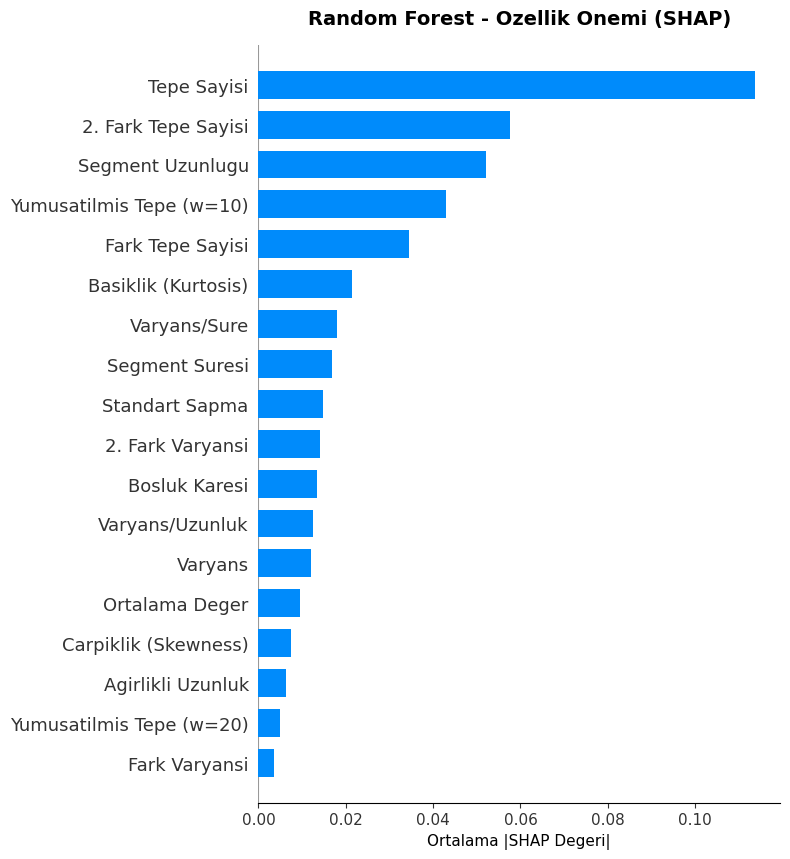

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(rf_shap_vals, X_test, feature_names=feature_labels,
                  plot_type="bar", show=False, max_display=20)
plt.title("Random Forest - Ozellik Onemi (SHAP)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Ortalama |SHAP Degeri|", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_rf_summary_bar.png'), dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

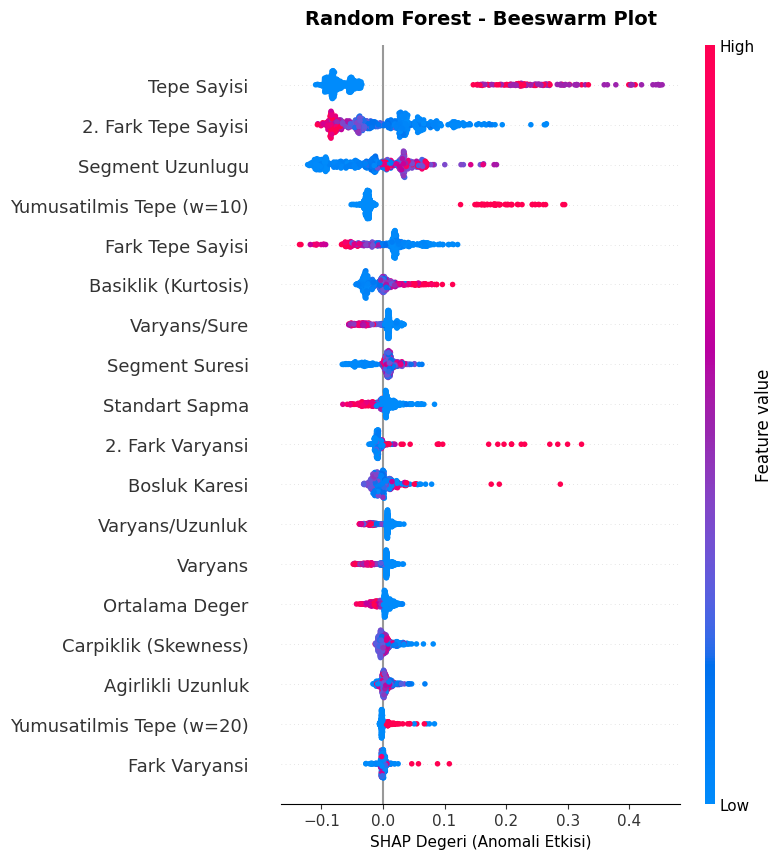

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(rf_shap_vals, X_test, feature_names=feature_labels,
                  show=False, max_display=20)
plt.title("Random Forest - Beeswarm Plot", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("SHAP Degeri (Anomali Etkisi)", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_rf_beeswarm.png'), dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

Ilk anomali ornegi: index 3


<Figure size 2000x300 with 0 Axes>

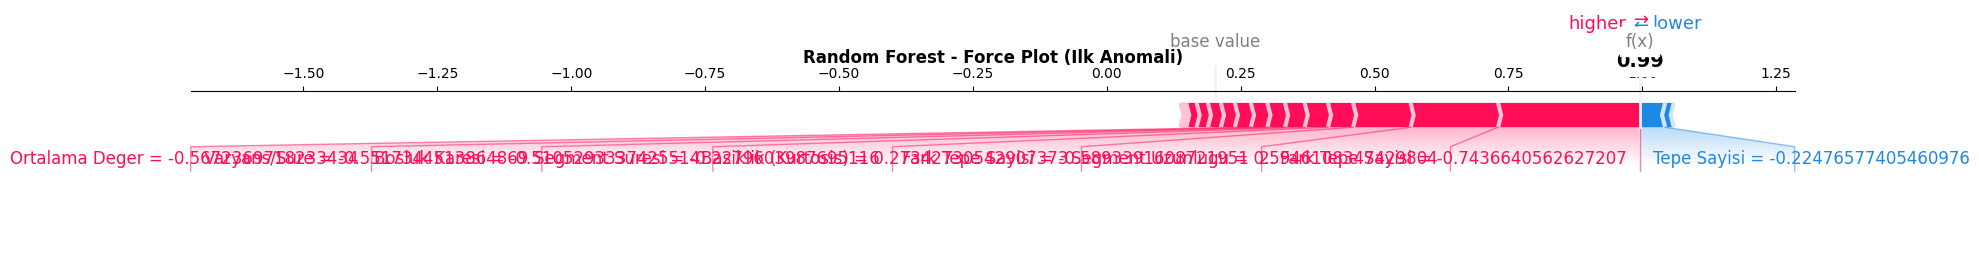

In [7]:
anomaly_indices = np.where(y_test == 1)[0]
first_anomaly_idx = anomaly_indices[0]
print(f"Ilk anomali ornegi: index {first_anomaly_idx}")

fig = plt.figure(figsize=(20, 3))
shap.force_plot(base_value=float(rf_expected_val), shap_values=rf_shap_vals[first_anomaly_idx],
                features=X_test[first_anomaly_idx], feature_names=feature_labels,
                matplotlib=True, show=False)
plt.title("Random Forest - Force Plot (Ilk Anomali)", fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_rf_force.png'), dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

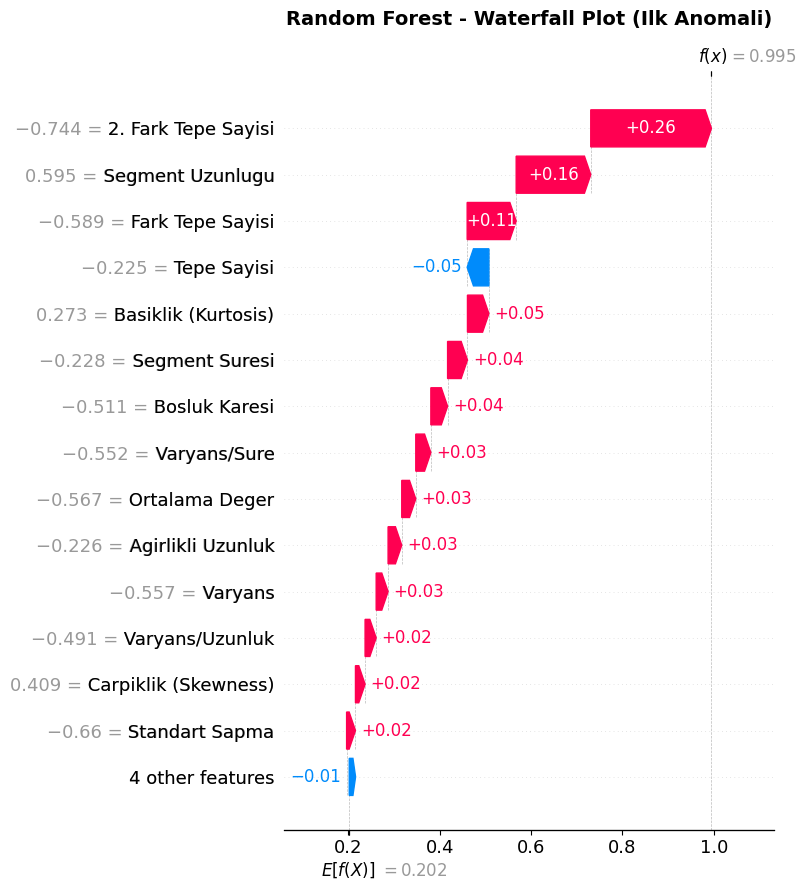

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
explanation = shap.Explanation(
    values=rf_shap_vals[first_anomaly_idx],
    base_values=rf_expected_val,
    data=X_test[first_anomaly_idx],
    feature_names=feature_labels
)
shap.plots.waterfall(explanation, show=False, max_display=15)
plt.title("Random Forest - Waterfall Plot (Ilk Anomali)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_rf_waterfall.png'), dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

### 2.2 XGBoost SHAP Analizi

XGBoost de agac tabanli oldugundan TreeExplainer kullanilir.

In [9]:
xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer.shap_values(X_test)

xgb_shap_vals = xgb_shap_values
xgb_expected_val = xgb_explainer.expected_value
if isinstance(xgb_expected_val, (list, np.ndarray)):
    xgb_expected_val = float(xgb_expected_val[0]) if len(np.array(xgb_expected_val).shape) > 0 else float(xgb_expected_val)
else:
    xgb_expected_val = float(xgb_expected_val)

print(f"XGB SHAP shape: {xgb_shap_vals.shape}")
print(f"XGB expected value: {xgb_expected_val:.4f}")

XGB SHAP shape: (529, 18)
XGB expected value: -1.6922


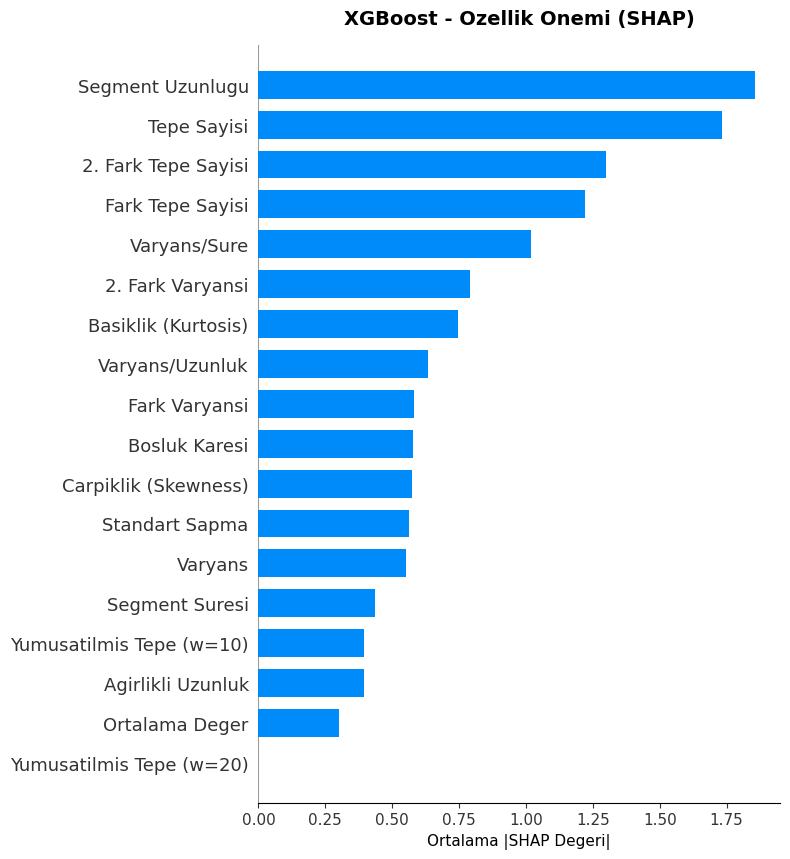

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(xgb_shap_vals, X_test, feature_names=feature_labels,
                  plot_type="bar", show=False, max_display=20)
plt.title("XGBoost - Ozellik Onemi (SHAP)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Ortalama |SHAP Degeri|", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_xgb_summary_bar.png'), dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

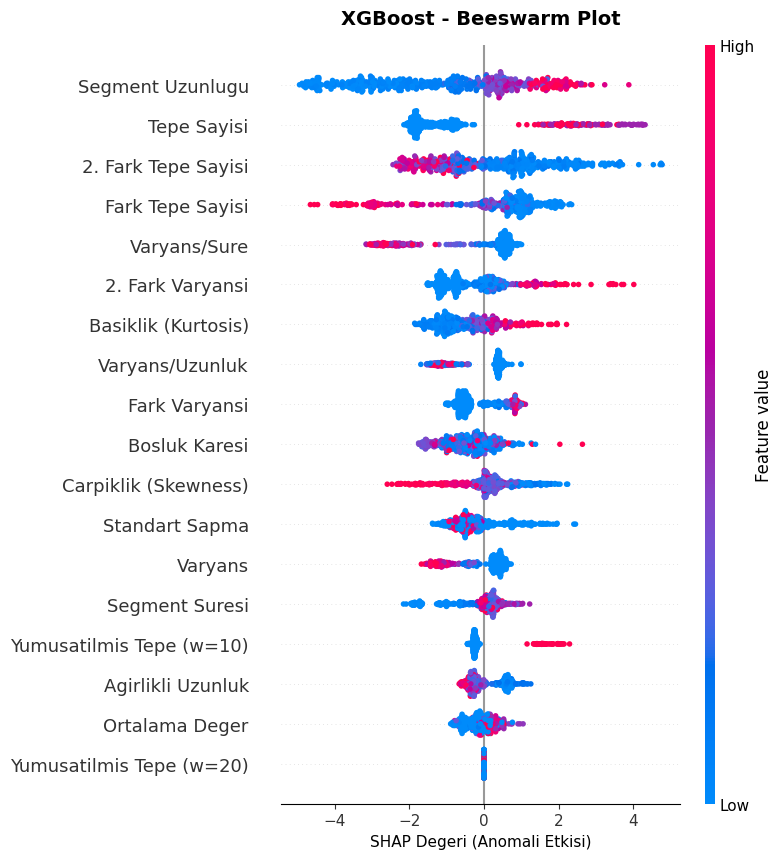

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(xgb_shap_vals, X_test, feature_names=feature_labels,
                  show=False, max_display=20)
plt.title("XGBoost - Beeswarm Plot", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("SHAP Degeri (Anomali Etkisi)", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_xgb_beeswarm.png'), dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

<Figure size 2000x300 with 0 Axes>

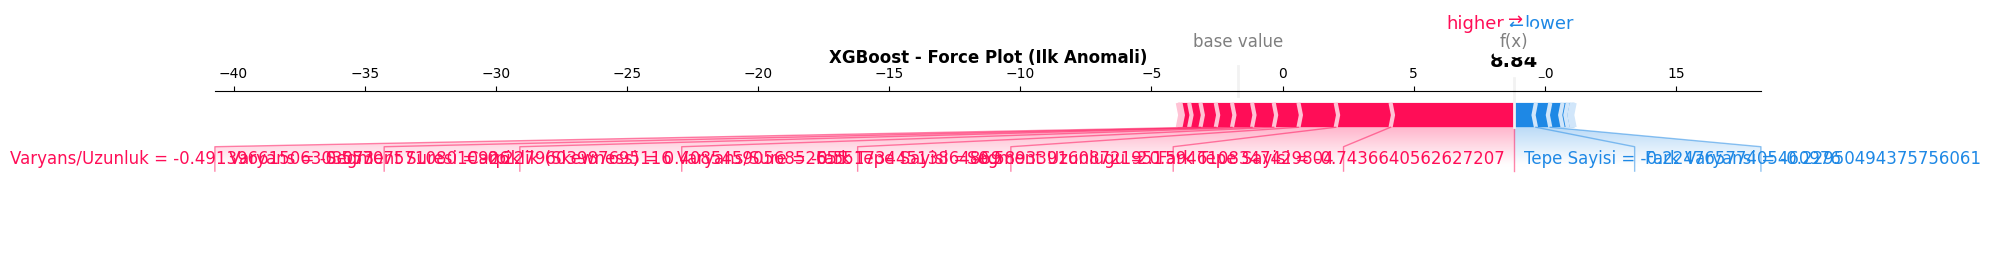

In [12]:
fig = plt.figure(figsize=(20, 3))
shap.force_plot(base_value=float(xgb_expected_val), shap_values=xgb_shap_vals[first_anomaly_idx],
                features=X_test[first_anomaly_idx], feature_names=feature_labels,
                matplotlib=True, show=False)
plt.title("XGBoost - Force Plot (Ilk Anomali)", fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_xgb_force.png'), dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

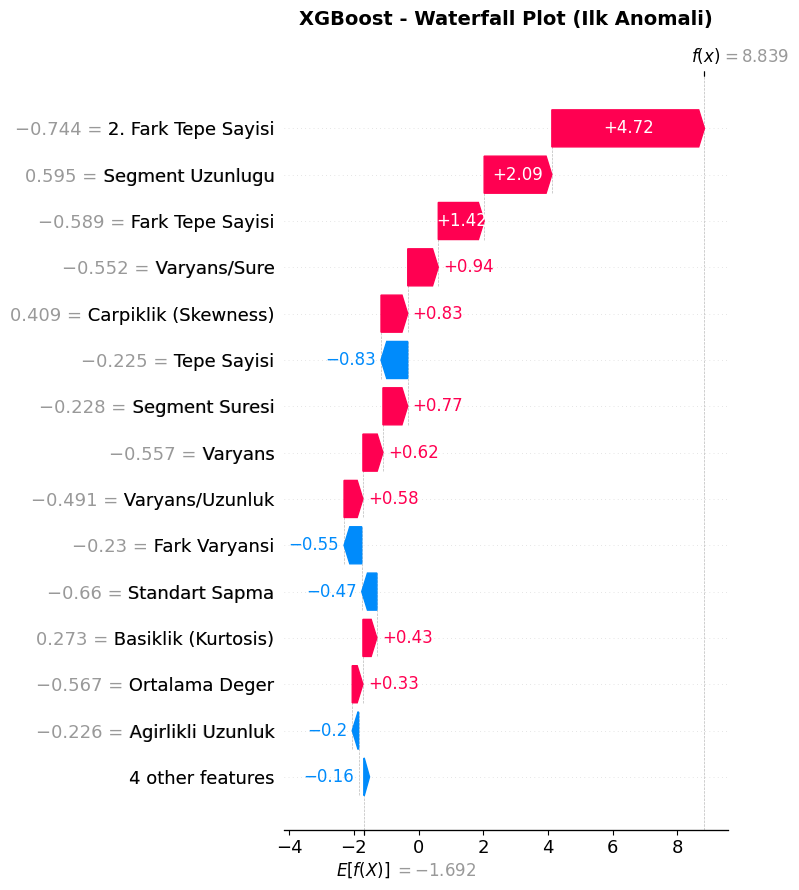

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))
explanation_xgb = shap.Explanation(
    values=xgb_shap_vals[first_anomaly_idx],
    base_values=xgb_expected_val,
    data=X_test[first_anomaly_idx],
    feature_names=feature_labels
)
shap.plots.waterfall(explanation_xgb, show=False, max_display=15)
plt.title("XGBoost - Waterfall Plot (Ilk Anomali)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_xgb_waterfall.png'), dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

### 2.3 MLP SHAP Analizi

MLP için KernelExplainer kullanılır. Bu yöntem modelden bağımsız çalışır ancak yavaş olduğundan yalnızca 100 örnek üzerinde hesaplanır.

In [14]:
background = shap.kmeans(X_test, 50)

def mlp_predict(X):
    if mlp_is_keras:
        return mlp_model.predict(X, verbose=0).flatten()
    return mlp_model.predict_proba(X)[:, 1]

mlp_explainer = shap.KernelExplainer(mlp_predict, background)
mlp_shap_vals = mlp_explainer.shap_values(X_test[:100], nsamples=200)
mlp_expected_val = float(np.array(mlp_explainer.expected_value).ravel()[0])

print(f"MLP SHAP shape: {np.array(mlp_shap_vals).shape}")
print(f"MLP expected value: {mlp_expected_val:.4f}")

  0%|          | 0/100 [00:00<?, ?it/s]

MLP SHAP shape: (100, 18)
MLP expected value: 0.1952


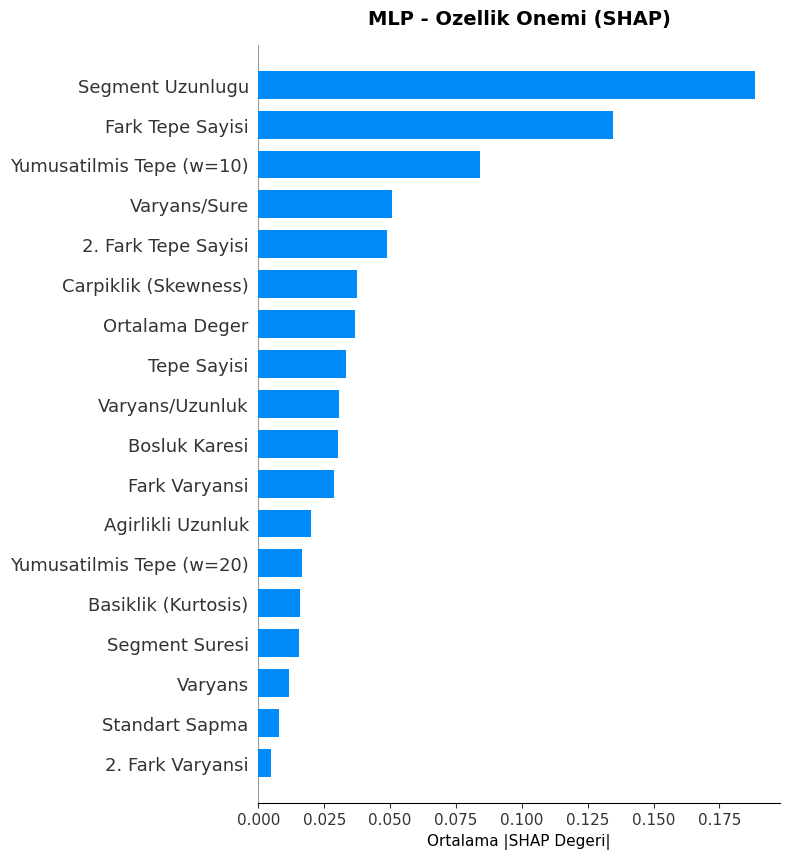

In [15]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(mlp_shap_vals, X_test[:100], feature_names=feature_labels,
                  plot_type="bar", show=False, max_display=20)
plt.title("MLP - Ozellik Onemi (SHAP)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Ortalama |SHAP Degeri|", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_mlp_summary_bar.png'), dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

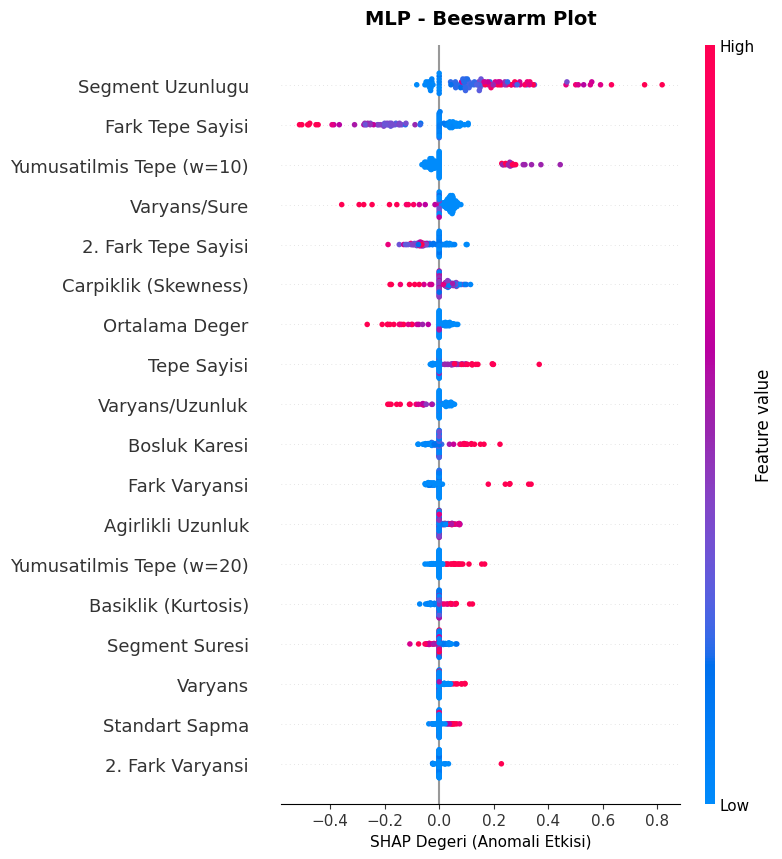

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(mlp_shap_vals, X_test[:100], feature_names=feature_labels,
                  show=False, max_display=20)
plt.title("MLP - Beeswarm Plot", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("SHAP Degeri (Anomali Etkisi)", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_mlp_beeswarm.png'), dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

<Figure size 2000x300 with 0 Axes>

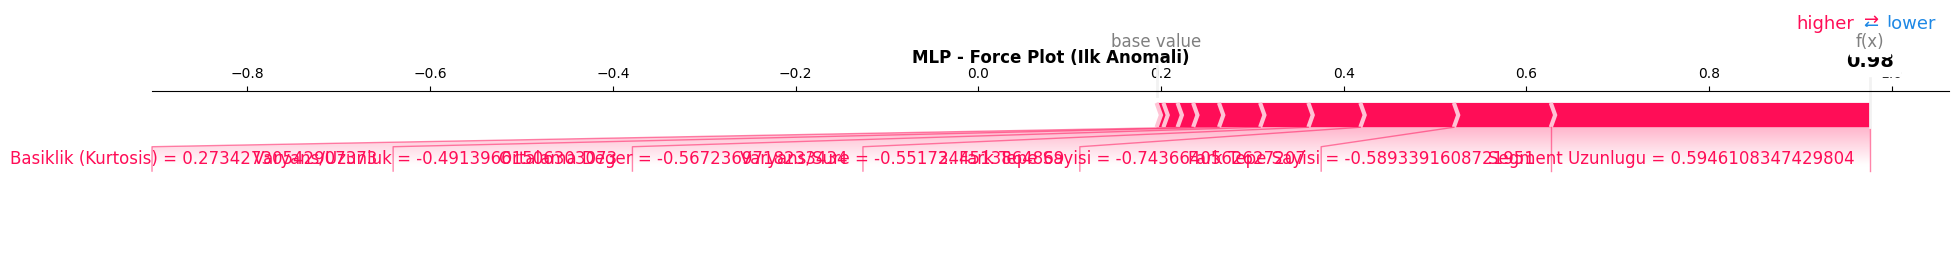

In [17]:
mlp_anomaly_indices = np.where(y_test[:100] == 1)[0]
if len(mlp_anomaly_indices) > 0:
    mlp_first_anom = mlp_anomaly_indices[0]
else:
    mlp_first_anom = 0

fig = plt.figure(figsize=(20, 3))
shap.force_plot(base_value=float(mlp_expected_val), shap_values=mlp_shap_vals[mlp_first_anom],
                features=X_test[mlp_first_anom], feature_names=feature_labels,
                matplotlib=True, show=False)
plt.title("MLP - Force Plot (Ilk Anomali)", fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_mlp_force.png'), dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

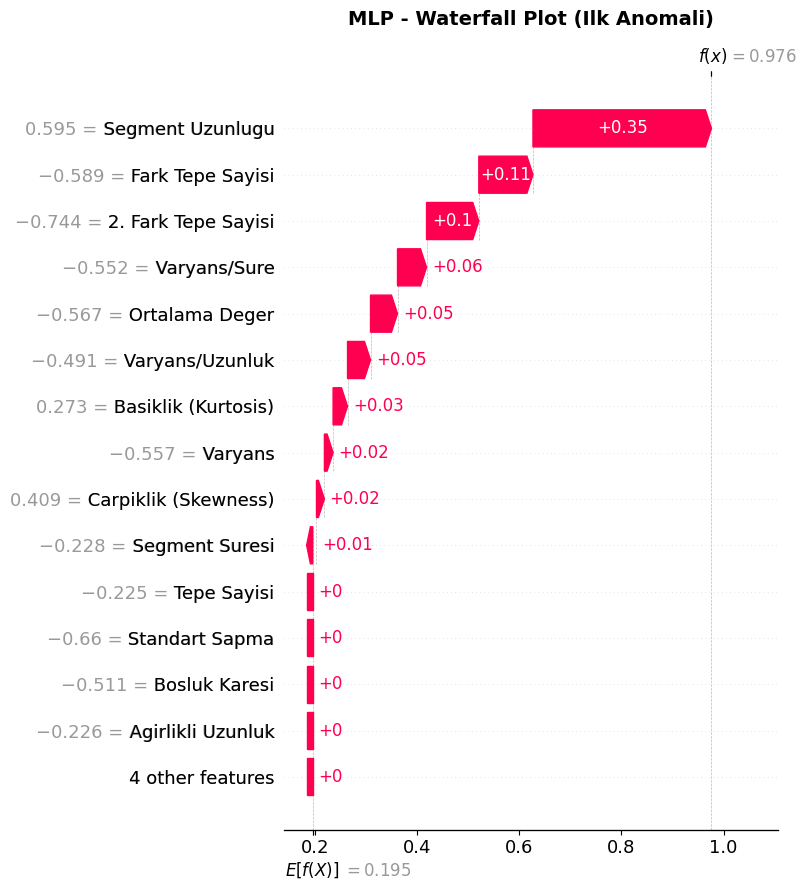

In [18]:
fig, ax = plt.subplots(figsize=(10, 8))
explanation_mlp = shap.Explanation(
    values=mlp_shap_vals[mlp_first_anom],
    base_values=mlp_expected_val,
    data=X_test[mlp_first_anom],
    feature_names=feature_labels
)
shap.plots.waterfall(explanation_mlp, show=False, max_display=15)
plt.title("MLP - Waterfall Plot (Ilk Anomali)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_mlp_waterfall.png'), dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

---
## Bölüm 3: Model Karşılaştırması

Random Forest ve XGBoost modellerinin SHAP özellik önemlerini tek grafikte karşılaştırır. Her iki modelin hangi özelliklere odaklandığını gösterir.

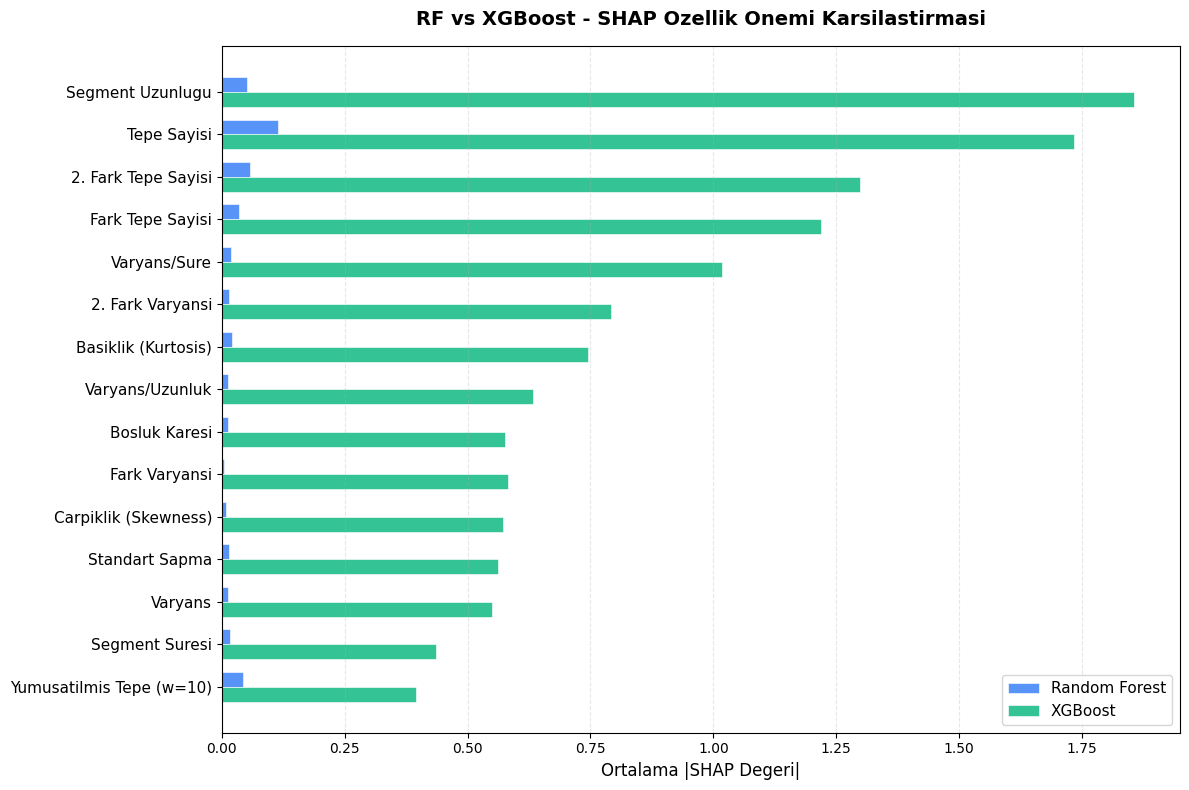

In [19]:
rf_importance = np.abs(rf_shap_vals).mean(axis=0)
xgb_importance = np.abs(xgb_shap_vals).mean(axis=0)

combined = rf_importance + xgb_importance
top_indices = np.argsort(combined)[-15:][::-1]

top_labels = [feature_labels[i] for i in top_indices]
top_rf = rf_importance[top_indices]
top_xgb = xgb_importance[top_indices]

fig, ax = plt.subplots(figsize=(12, 8))
y_pos = np.arange(len(top_labels))
bar_height = 0.35

bars1 = ax.barh(y_pos - bar_height/2, top_rf, bar_height, label='Random Forest',
                color='#3B82F6', alpha=0.85, edgecolor='white', linewidth=0.5)
bars2 = ax.barh(y_pos + bar_height/2, top_xgb, bar_height, label='XGBoost',
                color='#10B981', alpha=0.85, edgecolor='white', linewidth=0.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(top_labels, fontsize=11)
ax.set_xlabel('Ortalama |SHAP Degeri|', fontsize=12)
ax.set_title('RF vs XGBoost - SHAP Ozellik Onemi Karsilastirmasi', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='lower right')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'shap_model_karsilastirma.png'), dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

In [20]:
comparison_df = pd.DataFrame({
    'Ozellik': feature_labels,
    'RF |SHAP|': rf_importance,
    'XGB |SHAP|': xgb_importance,
    'Fark (RF-XGB)': rf_importance - xgb_importance,
})
comparison_df = comparison_df.sort_values('RF |SHAP|', ascending=False).reset_index(drop=True)
comparison_df.index += 1
print("\nOzellik Onemi Karsilastirmasi (buyukten kucuge):\n")
print(comparison_df.to_string())


Ozellik Onemi Karsilastirmasi (buyukten kucuge):

                     Ozellik  RF |SHAP|  XGB |SHAP|  Fark (RF-XGB)
1                Tepe Sayisi   0.113748    1.733584      -1.619837
2        2. Fark Tepe Sayisi   0.057670    1.297889      -1.240219
3           Segment Uzunlugu   0.052184    1.856484      -1.804299
4   Yumusatilmis Tepe (w=10)   0.042843    0.395588      -0.352745
5           Fark Tepe Sayisi   0.034399    1.218751      -1.184352
6        Basiklik (Kurtosis)   0.021333    0.745732      -0.724399
7               Varyans/Sure   0.017930    1.016804      -0.998874
8             Segment Suresi   0.016801    0.436008      -0.419207
9             Standart Sapma   0.014884    0.561050      -0.546166
10          2. Fark Varyansi   0.013990    0.791791      -0.777801
11             Bosluk Karesi   0.013399    0.576129      -0.562730
12           Varyans/Uzunluk   0.012396    0.633890      -0.621493
13                   Varyans   0.012109    0.550546      -0.538437
14         

---
## 3. Tüm Modeller için SHAP

In [21]:
import sys, time as _time
sys.path.insert(0, os.path.join('..', 'app'))
from utils.model_loader import load_all, predict as _predict

ALL_MODELS, THRESHOLDS, _scl, _td = load_all()
print(f"Yuklu (calistirilabilir) model: {len(ALL_MODELS)}")

TREE_MODELS = {"RandomForest", "XGBoost", "ExtraTrees", "GradientBoosting",
               "HistGradientBoosting", "LightGBM", "CatBoost", "DecisionTree",
               "AdaBoost", "Bagging"}

_anom = np.where(y_test == 1)[0][:80]   
_norm = np.where(y_test == 0)[0]
_rng = np.random.RandomState(42)
_sel_norm = _rng.choice(_norm, size=min(len(_norm), 20), replace=False)
explain_pos = np.sort(np.concatenate([_anom, _sel_norm]))
X_explain = X_test[explain_pos]
y_explain = y_test[explain_pos]
n_feat = X_test.shape[1]
background = shap.sample(X_test, 40, random_state=42)   
print(f"Aciklama seti: {X_explain.shape}  (anomali {int(y_explain.sum())}, normal {int((y_explain==0).sum())})")


def _tree_shap(model):
    expl = shap.TreeExplainer(model)
    sv = expl.shap_values(X_explain)
    if isinstance(sv, list):
        sv = sv[1]
    elif getattr(sv, 'ndim', 0) == 3:
        sv = sv[:, :, 1]
    ev = np.array(expl.expected_value).ravel()
    return np.asarray(sv), float(ev[1] if ev.size > 1 else ev[0])


def _kernel_shap(name, model):
    score_fn = lambda X: np.asarray(_predict(model, name, X, THRESHOLDS)[1]).ravel()
    expl = shap.KernelExplainer(score_fn, background)
    sv = np.asarray(expl.shap_values(X_explain, nsamples=30, silent=True, l1_reg=f"num_features({n_feat})"))
    if sv.ndim == 3:
        sv = sv[:, :, 1] if sv.shape[-1] > 1 else sv[..., 0]
    return sv, float(np.array(expl.expected_value).ravel()[0])


shap_export = {}
for _name in list(ALL_MODELS.keys()):
    _t0 = _time.time()
    try:
        if _name in TREE_MODELS:
            try:
                _sv, _ev = _tree_shap(ALL_MODELS[_name])
            except Exception:
                _sv, _ev = _kernel_shap(_name, ALL_MODELS[_name])
        else:
            _sv, _ev = _kernel_shap(_name, ALL_MODELS[_name])
        if _sv.shape != (len(X_explain), n_feat):
            raise ValueError(f"beklenmeyen SHAP boyutu {_sv.shape}")
        shap_export[_name] = {"values": _sv.astype('float32'), "expected": _ev}
        print(f"  {_name:24s} OK   ({_time.time()-_t0:5.1f}s)")
    except Exception as _e:
        print(f"  {_name:24s} ATLANDI ({type(_e).__name__}: {str(_e)[:55]})")

shap_models = list(shap_export.keys())
print(f"\nSHAP hesaplanan model: {len(shap_models)} / {len(ALL_MODELS)}")


Yuklu (calistirilabilir) model: 42
Aciklama seti: (100, 18)  (anomali 80, normal 20)
  RandomForest             OK   (  0.2s)
  XGBoost                  OK   (  0.0s)
  SVM                      OK   (  2.7s)
  LightGBM                 OK   (  0.1s)
  CatBoost                 OK   (  0.1s)
  Stacking Ensemble        OK   ( 23.2s)
  ExtraTrees               OK   (  1.1s)
  GradientBoosting         OK   (  0.0s)
  HistGradientBoosting     OK   (  0.1s)
  AdaBoost                 OK   (  1.8s)
  KNN                      OK   (  1.0s)
  LogisticRegression       OK   (  0.2s)
  DecisionTree             OK   (  0.0s)
  NaiveBayes               OK   (  0.2s)
  Voting Ensemble          OK   ( 49.3s)
  LDA                      OK   (  0.2s)
  QDA                      OK   (  0.2s)
  Bagging                  OK   ( 14.0s)
  Ridge                    OK   (  0.4s)
  SGD                      OK   (  0.4s)
  LSVC                     OK   (  0.4s)
  XGBOD                    OK   ( 92.2s)
  MLP        

---
## Bölüm 4: SHAP Değerlerini Kaydet

Hesaplanan tüm SHAP değerleri, beklenen değerler, özellik isimleri ve test verisi `models/shap_values.pkl` dosyasına kaydedilir. Bu dosya Dash arayüzünde kullanılacaktır.

In [22]:
shap_data = {
    'feature_cols': feature_cols,
    'feature_labels': feature_labels,
    'feature_names_tr': FEATURE_NAMES_TR,
    'X_test': X_explain,
    'y_test': y_explain,
    'shap_models': shap_models,
}
for _name, _d in shap_export.items():
    shap_data[f'{_name}_shap_values'] = _d['values']
    shap_data[f'{_name}_expected_value'] = _d['expected']

for _short, _full in [('rf', 'RandomForest'), ('xgb', 'XGBoost'), ('mlp', 'MLP')]:
    if _full in shap_export:
        shap_data[f'{_short}_shap_values'] = shap_export[_full]['values']
        shap_data[f'{_short}_expected_value'] = shap_export[_full]['expected']

save_path = os.path.join(MODEL_DIR, 'shap_values.pkl')
joblib.dump(shap_data, save_path, compress=3)
file_size_mb = os.path.getsize(save_path) / (1024 * 1024)
print(f"SHAP degerleri kaydedildi: {save_path}")
print(f"Dosya boyutu: {file_size_mb:.1f} MB")
print(f"Kaydedilen model sayisi: {len(shap_models)} -> {shap_models}")


SHAP degerleri kaydedildi: /home/keskin/Uydu-Telemetri-Anomali-Tespiti/models/shap_values.pkl
Dosya boyutu: 0.3 MB
Kaydedilen model sayisi: 39 -> ['RandomForest', 'XGBoost', 'SVM', 'LightGBM', 'CatBoost', 'Stacking Ensemble', 'ExtraTrees', 'GradientBoosting', 'HistGradientBoosting', 'AdaBoost', 'KNN', 'LogisticRegression', 'DecisionTree', 'NaiveBayes', 'Voting Ensemble', 'LDA', 'QDA', 'Bagging', 'Ridge', 'SGD', 'LSVC', 'XGBOD', 'MLP', 'IsolationForest', 'OneClassSVM', 'KMeans', 'LOF', 'GMM', 'EllipticEnvelope', 'PCA', 'DBSCAN', 'ECOD', 'COPOD', 'HBOS', 'CBLOF', 'ABOD', 'LODA', 'INNE', 'LMDD']


In [24]:
for fname in sorted(os.listdir(FIG_DIR)):
    if 'shap' in fname.lower():
        fpath = os.path.join(FIG_DIR, fname)
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  {fname} ({size_kb:.0f} KB)")
        
print(f"shap_values.pkl kaydedildi: {os.path.join(MODEL_DIR, 'shap_values.pkl')}")

  shap_mlp_beeswarm.png (231 KB)
  shap_mlp_force.png (116 KB)
  shap_mlp_summary_bar.png (148 KB)
  shap_mlp_waterfall.png (209 KB)
  shap_model_karsilastirma.png (165 KB)
  shap_rf_beeswarm.png (276 KB)
  shap_rf_force.png (143 KB)
  shap_rf_summary_bar.png (152 KB)
  shap_rf_waterfall.png (219 KB)
  shap_xgb_beeswarm.png (338 KB)
  shap_xgb_force.png (151 KB)
  shap_xgb_summary_bar.png (151 KB)
  shap_xgb_waterfall.png (225 KB)
shap_values.pkl kaydedildi: /home/keskin/Uydu-Telemetri-Anomali-Tespiti/models/shap_values.pkl
